cuda:0


/home/timotheewsl/PER/Guillaume/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/timotheewsl/PER/Guillaume/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


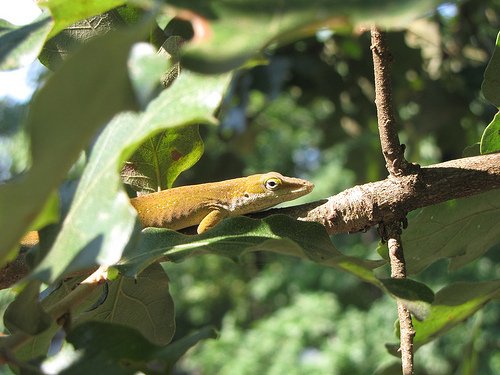

In [1]:
import torch
from torchvision.models.vgg import vgg16_bn
import torchvision.transforms as T
from PIL import Image
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat

device = "cuda:0" if torch.cuda.is_available() else "cpu"
#device = "cpu"
print(device)
model = vgg16_bn(True).to(device)
model.eval()

canonizers = [SequentialMergeBatchNorm()]
composite = EpsilonPlusFlat(canonizers)

image = Image.open("data/lizard.jpg")
image

In [2]:
import torchvision
from crp.concepts import ChannelConcept
from crp.helper import get_layer_names
from crp.attribution import CondAttribution
from crp.visualization import FeatureVisualization
from zennitcrp.tutorials.VGG16_ImageNet.download_imagenet import download

cc = ChannelConcept()

layer_names = get_layer_names(model, [torch.nn.Conv2d, torch.nn.Linear])
layer_map = {layer : cc for layer in layer_names}

attribution = CondAttribution(model)

# separate normalization from resizing for plotting purposes later
transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
preprocessing =  T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

data_path = "ImageNet_data" #TODO fill or run download below

if data_path is None:
    # download ImageNet validation set
    data_path = "ImageNet_data"
    download(data_path)

# apply no normalization here!
imagenet_data = torchvision.datasets.ImageNet(data_path, transform=transform, split="val")

In [3]:
fv_path = "VGG16_ImageNet"
fv = FeatureVisualization(attribution, imagenet_data, layer_map, preprocess_fn=preprocessing, path=fv_path)
print(torch.__version__)

2.7.0.dev20250209+cu128


In [4]:
# it will take approximately 20 min on a Titan RTX
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True

saved_files = fv.run(composite, 0, len(imagenet_data), 32, 100)

Running Analysis...


100%|██████████| 1563/1563 [30:22<00:00,  1.17s/it] 


100%|██████████| 16000/16000 [00:28<00:00, 567.52it/s]


/home/timotheewsl/PER/Guillaume/.venv/lib/python3.10/site-packages/crp/image.py:288: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


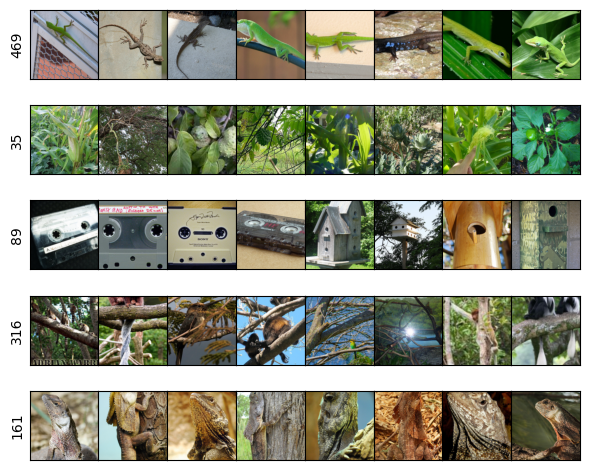

In [5]:
%matplotlib inline
from crp.image import plot_grid

ref_c = fv.get_max_reference([469, 35, 89, 316, 161], "features.40", "relevance", (0, 8))

plot_grid(ref_c, figsize=(6, 5), padding=False)

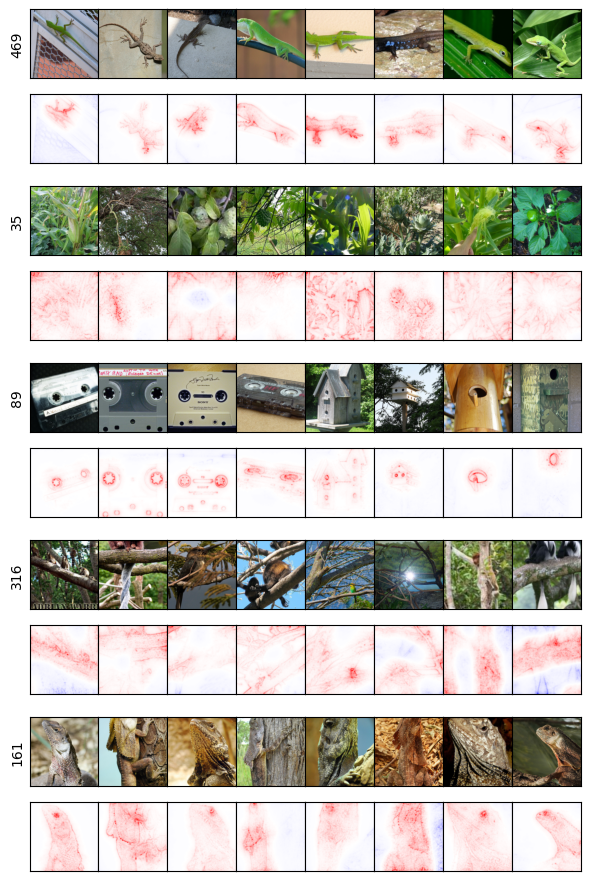

In [6]:
ref_c = fv.get_max_reference([469, 35, 89, 316, 161], "features.40", "relevance", (0, 8), composite=composite, plot_fn=None)

plot_grid(ref_c, figsize=(6, 9))

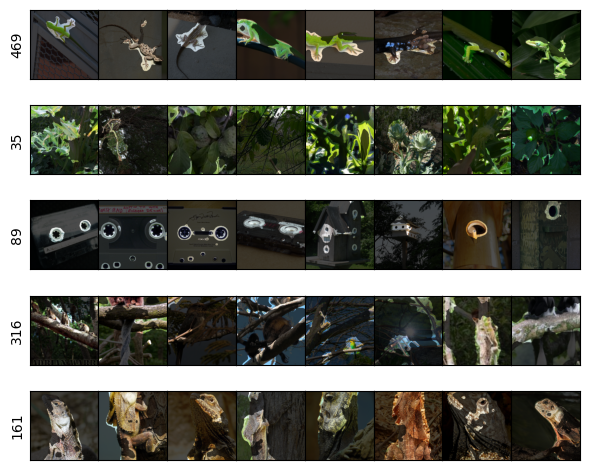

In [7]:
from crp.image import vis_opaque_img

ref_c = fv.get_max_reference([469, 35, 89, 316, 161], "features.40", "relevance", (0, 8), composite=composite, plot_fn=vis_opaque_img)

plot_grid(ref_c, cmap="bwr", symmetric=True, figsize=(6, 5))

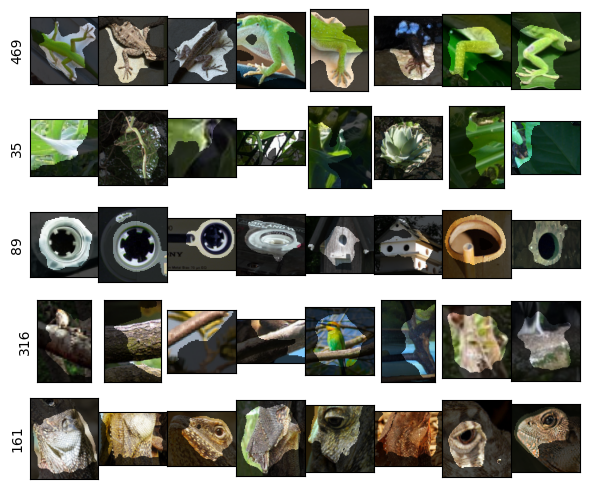

In [8]:
ref_c = fv.get_max_reference([469, 35, 89, 316, 161], "features.40", "relevance", (0, 8), rf=True, composite=composite, plot_fn=vis_opaque_img)

plot_grid(ref_c, figsize=(6, 5), padding=False)

In [15]:
import numpy as np
print(np.__version__)  # Doit afficher 1.26.4

targets, rel = fv.compute_stats(89, "features.40", "relevance", top_N=5, norm=True)
targets, rel

1.26.4


(array([481, 448, 684, 710,  40]),
 tensor([1.0000, 0.9068, 0.5283, 0.4171, 0.3877]))

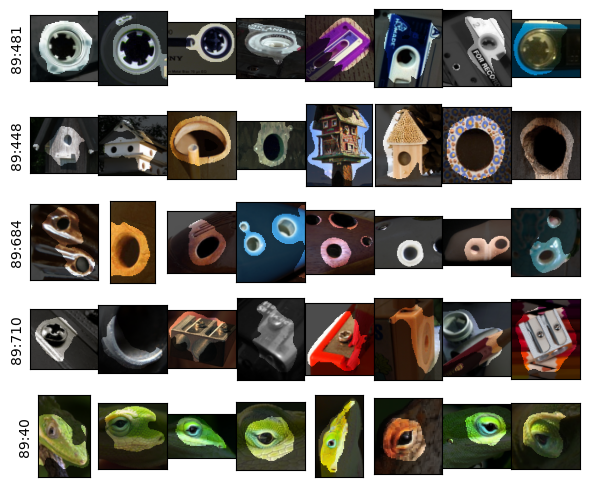

In [16]:
ref_t = fv.get_stats_reference(89, "features.40", targets, "relevance", (0, 8), rf=True, composite=composite, plot_fn=vis_opaque_img)

plot_grid(ref_t, figsize=(6, 5), padding=False)

In [11]:
from crp.cache import ImageCache

cache = ImageCache(path="cache")

fv = FeatureVisualization(attribution, imagenet_data, layer_map, preprocess_fn=preprocessing, path=fv_path, cache=cache)

In [12]:
%%time
ref_c = fv.get_max_reference([469, 35, 89, 316, 161], "features.40", "relevance", (0, 8), rf=True, composite=composite)

CPU times: user 9.21 ms, sys: 0 ns, total: 9.21 ms
Wall time: 65.6 ms


In [13]:
%%time
ref_c = fv.get_max_reference([469, 35, 89, 316, 161], "features.40", "relevance", (0, 8), rf=True, composite=composite)

CPU times: user 4.49 ms, sys: 470 μs, total: 4.96 ms
Wall time: 4.52 ms


In [14]:
from crp.helper import get_output_shapes
import numpy as np

layer_names = get_layer_names(model, [torch.nn.Conv2d])
output_shape = get_output_shapes(model, fv.get_data_sample(0)[0], layer_names)
layer_id_map = {l_name: np.arange(0, out[0]) for l_name, out in output_shape.items()}

fv.precompute_ref(layer_id_map,  plot_list=[vis_opaque_img], mode="relevance", r_range=(0, 16), composite=composite, rf=True, batch_size=32, stats=False)

Layer: features.0


100%|██████████| 64/64 [00:11<00:00,  5.75it/s]


Layer: features.3


100%|██████████| 64/64 [00:10<00:00,  6.25it/s]


Layer: features.7


...

100%|██████████| 512/512 [01:49<00:00,  4.66it/s]


Layer: features.37


100%|██████████| 512/512 [02:02<00:00,  4.18it/s]


Layer: features.40


100%|██████████| 512/512 [02:03<00:00,  4.14it/s]
